---
## Ejercicio 3 — GAN sobre configuraciones del modelo de Ising 2D

Ahora trabajaremos con `ising_dataset.pt`, que contiene configuraciones del modelo de Ising ya simuladas. Cada muestra puede verse como una imagen binaria con espines `-1/+1`, según el preprocesado.

1. Cargar el subconjunto de ising_dataset.pt utilizado anteriormente. Preprocesarlo para seleccionar solo las imagenes por encima de la T_c. 
2. Inspeccionar varias configuraciones reales y discutir qué estructura espacial aparece.
3. Entrenar una GAN de las vistas en el curso a eleccion.
4. Visualizar muestras generadas y compararlas con las reales.
5. Monitorear `d_loss` y `g_loss` durante el entrenamiento.
6. Repetir el ejercicio pero esta vez utilizando solo las imagenes por debajo de T_c. Las imágenes generadas, se parecen a las utilizadas para entrenar? 
7. (Opcional) repetir el ejercicio de la guía 02, pero con un conjunto de imágenes generadas por encima y por debajo de la T_c, utilizando ambos modelos entrenados. Logramos entrenar un clasificador con estos datos?


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import torch


# Ruta al dataset de Ising
ising_path = Path(r"G:\Mi unidad\2026\APBFpractica\data\ising_dataset.pt")
ising_data = torch.load(ising_path, map_location="cpu")
print(f"Archivo cargado: {ising_path}")
print(f"Tipo de objeto: {type(ising_data)}")

# Si el archivo es un diccionario, identificamos las claves de datos y etiquetas
if isinstance(ising_data, dict):
    print(f"Claves disponibles: {list(ising_data.keys())}")

    # Caso estándar: claves X_train / y_train / X_test / y_test
    if {"X_train", "y_train", "X_test", "y_test"}.issubset(ising_data.keys()):
        x = torch.cat([torch.as_tensor(ising_data["X_train"]), torch.as_tensor(ising_data["X_test"])], dim=0)
        y = torch.cat([torch.as_tensor(ising_data["y_train"]), torch.as_tensor(ising_data["y_test"])], dim=0)
    else:
        # Búsqueda de claves alternativas para datos y etiquetas
        x = None
        y = None
        for x_key in ["x", "X", "data", "images", "configs", "configurations"]:
            if x_key in ising_data:
                x = ising_data[x_key]
                break
        for y_key in ["y", "Y", "labels", "target", "targets", "temperature_label"]:
            if y_key in ising_data:
                y = ising_data[y_key]
                break

        if x is None or y is None:
            raise KeyError("No se pudieron identificar las claves de datos y etiquetas en el archivo .pt")
else:
    # Si no es un diccionario, se espera una tupla o lista con (datos, etiquetas)
    if not isinstance(ising_data, (list, tuple)) or len(ising_data) < 2:
        raise TypeError("Se esperaba un dict o una tupla/lista con datos y etiquetas.")
    x, y = ising_data[0], ising_data[1]

x = torch.as_tensor(x)
y = torch.as_tensor(y).long().view(-1)
print(f"Shape de x: {tuple(x.shape)}")
print(f"Shape de y: {tuple(y.shape)}")

# Separamos configuraciones por encima y por debajo de la temperatura crítica Tc
above_tc_mask = (y == 1)
x_above_tc = x[above_tc_mask]
y_above_tc = y[above_tc_mask]
print(f"Subset por encimaB de Tc: {len(x_above_tc)} muestras")

x_below_tc = x[~above_tc_mask]
y_below_tc = y[~above_tc_mask]
print(f"Subset por debajo de Tc: {len(x_below_tc)} muestras")


Archivo cargado: G:\Mi unidad\2026\APBFpractica\data\ising_dataset.pt
Tipo de objeto: <class 'dict'>
Claves disponibles: ['X_train', 'y_train', 'X_test', 'y_test']
Shape de x: (1000, 625)
Shape de y: (1000,)
Subset por encimaB de Tc: 550 muestras
Subset por debajo de Tc: 450 muestras


In [2]:
import torch
from torch import nn

# Generador CNN: recibe un vector latente z y produce una imagen 25x25
class GeneratorCNN(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()
        self.latent_dim = latent_dim

        # Proyección lineal del vector latente a un mapa de características 6x6
        self.decoder_input = nn.Sequential(
            nn.Linear(latent_dim, 128 * 6 * 6),
            nn.ReLU(),
            nn.Unflatten(1, (128, 6, 6))
        )

        # Upsampling + Conv2d para evitar artefactos de tablero de ajedrez
        # y soportar padding circular (condiciones de borde periódicas)
        self.decoder = nn.Sequential(
            nn.Upsample(size=(12, 12), mode='nearest'),
            nn.Conv2d(128, 64, kernel_size=3, stride=1, padding=1, padding_mode='circular'),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Upsample(size=(25, 25), mode='nearest'),
            nn.Conv2d(64, 1, kernel_size=3, stride=1, padding=1, padding_mode='circular'),
            nn.Tanh(),
        )

    def forward(self, z):
        return self.decoder(self.decoder_input(z))


# Discriminador CNN: recibe una imagen 25x25 y produce un logit (real vs. falsa)
class DiscriminatorCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            # 25x25 -> 13x13
            nn.Conv2d(1, 4, kernel_size=3, stride=2, padding=1, padding_mode='circular'),
            nn.LeakyReLU(0.2),

            # 13x13 -> 7x7
            nn.Conv2d(4, 8, kernel_size=3, stride=2, padding=1, padding_mode='circular'),
            nn.LeakyReLU(0.2),

            nn.Flatten(),
            nn.Linear(8 * 7 * 7, 8),
            nn.LeakyReLU(0.2),
            nn.Linear(8, 1),
        )

    def forward(self, x):
        return self.encoder(x)


In [3]:
LATENT_DIM = 32
bce_logits = nn.BCEWithLogitsLoss()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Genera vectores latentes aleatorios de dimensión LATENT_DIM
def sample_latent(n_samples, latent_dim=LATENT_DIM, device=DEVICE):
    return torch.randn(n_samples, latent_dim, device=device)


# Genera imágenes sintéticas sin acumular gradientes
@torch.no_grad()
def generate_samples(generator, n_samples):
    z = sample_latent(n_samples, device=next(generator.parameters()).device)
    return generator(z)


def train_gan(generator, discriminator, data, epochs=800, batch_size=64, lr_g=2e-4, lr_d=1e-4,
              alpha_d_loss=0.5, label_smoothing=0.1, noise_std_max=0.05, verbose_every=100):
    generator = generator.to(DEVICE)
    discriminator = discriminator.to(DEVICE)
    data = data.to(DEVICE)

    # Optimizadores Adam con betas estándar para GANs
    g_optimizer = torch.optim.Adam(generator.parameters(), lr=lr_g, betas=(0.5, 0.999), weight_decay=1e-5)
    d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=lr_d, betas=(0.5, 0.999), weight_decay=1e-3)

    history = {"g_loss": [], "d_loss": [], "real_score": [], "fake_score": []}

    for epoch in range(1, epochs + 1):
        # Permutación aleatoria de los datos en cada época
        perm = torch.randperm(data.size(0), device=data.device)
        total_g = total_d = total_real_score = total_fake_score = 0.0
        n_seen = 0

        # Ruido decreciente que se añade a las imágenes para estabilizar el entrenamiento
        noise_scale = noise_std_max * (1.0 - (epoch - 1) / max(epochs - 1, 1))

        for i in range(0, data.size(0), batch_size):
            idx = perm[i : i + batch_size]
            real_batch = data[idx]
            current_batch_size = real_batch.size(0)

            # Etiquetas suavizadas: reales cerca de 1, falsas cerca de 0
            real_targets = torch.empty(current_batch_size, 1, device=data.device).uniform_(1.0 - label_smoothing, 1.0)
            fake_targets = torch.empty(current_batch_size, 1, device=data.device).uniform_(0.0, label_smoothing)

            # Genera un batch falso
            z = sample_latent(current_batch_size, device=data.device)
            fake_batch = generator(z)

            # Añade ruido a las entradas del discriminador si corresponde
            if noise_scale > 0:
                real_batch_input = real_batch + noise_scale * torch.randn_like(real_batch)
                fake_batch_input = fake_batch.detach() + noise_scale * torch.randn_like(fake_batch)
            else:
                real_batch_input = real_batch
                fake_batch_input = fake_batch.detach()

            # ------- Paso del discriminador -------
            real_logits = discriminator(real_batch_input)
            fake_logits = discriminator(fake_batch_input)

            d_loss_real = bce_logits(real_logits, real_targets)
            d_loss_fake = bce_logits(fake_logits, fake_targets)
            d_loss = alpha_d_loss * (d_loss_real + d_loss_fake)

            d_optimizer.zero_grad()
            d_loss.backward()
            torch.nn.utils.clip_grad_norm_(discriminator.parameters(), max_norm=5.0)
            d_optimizer.step()

            # ------- Paso del generador -------
            z = sample_latent(current_batch_size, device=data.device)
            generated_batch = generator(z)
            generated_logits = discriminator(generated_batch)

            # El generador quiere que el discriminador clasifique sus imágenes como reales
            g_targets = torch.ones(current_batch_size, 1, device=data.device)
            g_loss = bce_logits(generated_logits, g_targets)

            g_optimizer.zero_grad()
            g_loss.backward()
            torch.nn.utils.clip_grad_norm_(generator.parameters(), max_norm=5.0)
            g_optimizer.step()

            # Acumulamos métricas ponderadas por tamaño de batch
            total_d += d_loss.item() * current_batch_size
            total_g += g_loss.item() * current_batch_size
            total_real_score += torch.sigmoid(real_logits).mean().item() * current_batch_size
            total_fake_score += torch.sigmoid(fake_logits).mean().item() * current_batch_size
            n_seen += current_batch_size

        # Guardamos métricas promedio de la época
        history["d_loss"].append(total_d / n_seen)
        history["g_loss"].append(total_g / n_seen)
        history["real_score"].append(total_real_score / n_seen)
        history["fake_score"].append(total_fake_score / n_seen)

        if epoch % verbose_every == 0 or epoch == 1:
            print(
                f"epoch={epoch:4d}  d_loss={history['d_loss'][-1]:.4f}  "
                f"g_loss={history['g_loss'][-1]:.4f}  "
                f"D(real)={history['real_score'][-1]:.3f}  "
                f"D(fake)={history['fake_score'][-1]:.3f}"
            )

    return history


In [4]:
# Instanciamos generador y discriminador para configuraciones por encima de Tc
generator_above_tc = GeneratorCNN(latent_dim=LATENT_DIM)
discriminator_above_tc = DiscriminatorCNN()

# Reformateamos el dataset a (N, 1, 25, 25) para las convoluciones
x_above_tc_reshaped = x_above_tc.view(-1, 1, 25, 25).float()

history_above_tc = train_gan(
    generator_above_tc,
    discriminator_above_tc,
    x_above_tc_reshaped,
    epochs=500,
    batch_size=64,
    lr_g=2e-4,
    lr_d=1e-4,
    verbose_every=10,
)


epoch=   1  d_loss=0.6942  g_loss=0.7423  D(real)=0.476  D(fake)=0.476
epoch=  10  d_loss=0.6920  g_loss=0.7189  D(real)=0.489  D(fake)=0.488
epoch=  20  d_loss=0.6958  g_loss=0.6924  D(real)=0.497  D(fake)=0.500
epoch=  30  d_loss=0.6932  g_loss=0.6979  D(real)=0.498  D(fake)=0.498
epoch=  40  d_loss=0.6934  g_loss=0.6949  D(real)=0.499  D(fake)=0.500
epoch=  50  d_loss=0.6938  g_loss=0.6938  D(real)=0.499  D(fake)=0.500
epoch=  60  d_loss=0.6954  g_loss=0.6902  D(real)=0.499  D(fake)=0.502
epoch=  70  d_loss=0.6947  g_loss=0.6897  D(real)=0.500  D(fake)=0.502
epoch=  80  d_loss=0.6946  g_loss=0.6890  D(real)=0.501  D(fake)=0.502
epoch=  90  d_loss=0.6936  g_loss=0.6937  D(real)=0.499  D(fake)=0.500
epoch= 100  d_loss=0.6943  g_loss=0.6945  D(real)=0.498  D(fake)=0.499
epoch= 110  d_loss=0.6935  g_loss=0.6955  D(real)=0.499  D(fake)=0.499
epoch= 120  d_loss=0.6942  g_loss=0.6917  D(real)=0.500  D(fake)=0.501
epoch= 130  d_loss=0.6945  g_loss=0.6928  D(real)=0.499  D(fake)=0.500
epoch=

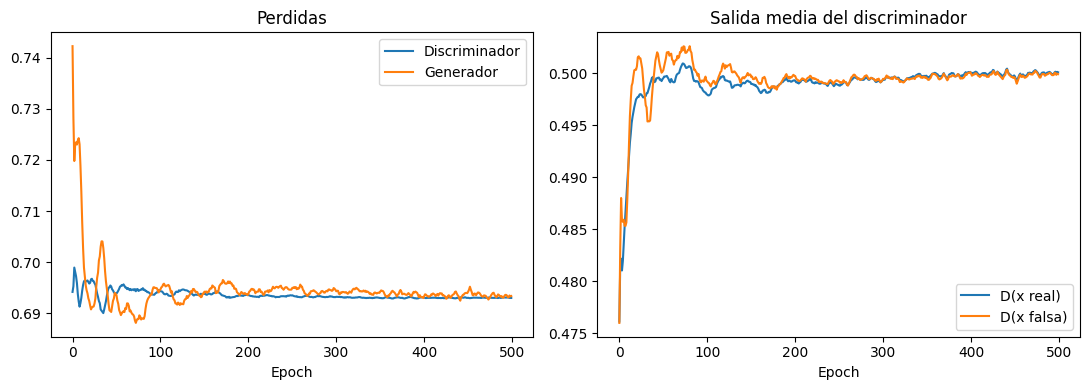

In [5]:
def plot_training_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    # Pérdidas del generador y discriminador por época
    axes[0].plot(history["d_loss"], label="Discriminador")
    axes[0].plot(history["g_loss"], label="Generador")
    axes[0].set_title("Perdidas")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    # Probabilidad media asignada por el discriminador a imágenes reales y falsas
    axes[1].plot(history["real_score"], label="D(x real)")
    axes[1].plot(history["fake_score"], label="D(x falsa)")
    axes[1].set_title("Salida media del discriminador")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_training_history(history_above_tc)


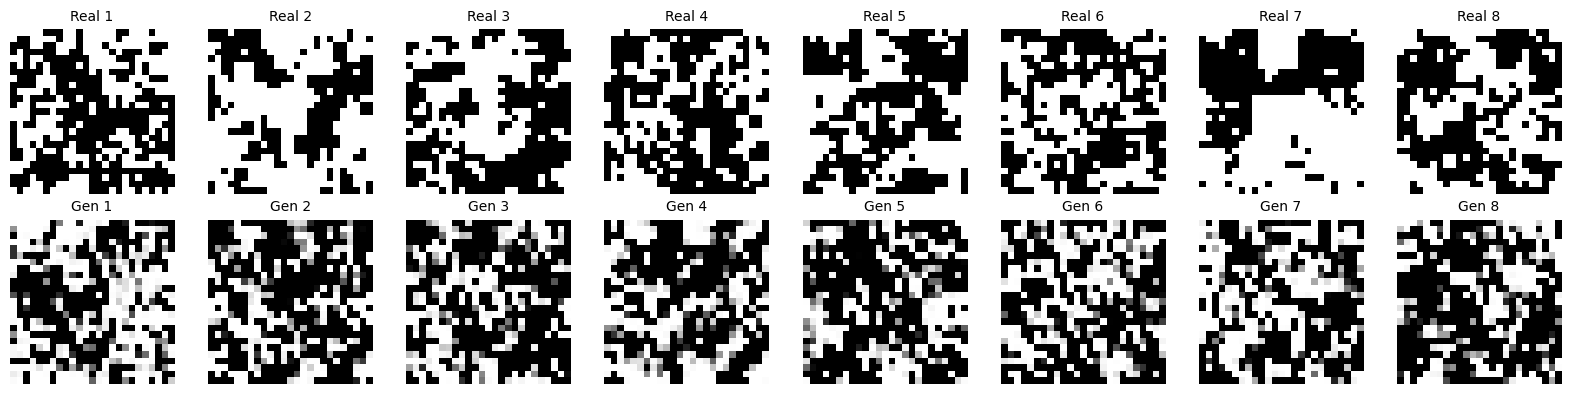

In [34]:
@torch.no_grad()
def compare_generated_vs_real(generator, real_data, n_samples=8):
    device = next(generator.parameters()).device
    generator.eval()

    # Genera muestras sintéticas a partir de vectores latentes aleatorios
    z = torch.randn(n_samples, LATENT_DIM, device=device)
    generated = generator(z).cpu()

    # Selecciona muestras reales aleatorias del dataset
    idx = torch.randperm(len(real_data))[:n_samples]
    real_samples = real_data[idx].view(-1, 1, 25, 25).float()

    # Grilla: fila 0 = reales, fila 1 = generadas
    fig, axes = plt.subplots(2, n_samples, figsize=(n_samples * 2, 4))

    for i in range(n_samples):
        axes[0, i].imshow(real_samples[i].squeeze().numpy(), cmap="gray", vmin=-1, vmax=1)
        axes[0, i].set_title(f"Real {i+1}", fontsize=10)
        axes[0, i].axis("off")

        axes[1, i].imshow(generated[i].squeeze().numpy(), cmap="gray", vmin=0, vmax=1)
        axes[1, i].set_title(f"Gen {i+1}", fontsize=10)
        axes[1, i].axis("off")

    axes[0, 0].set_ylabel("Real", fontsize=12, fontweight="bold")
    axes[1, 0].set_ylabel("Generada", fontsize=12, fontweight="bold")

    plt.tight_layout()
    plt.show()

compare_generated_vs_real(generator_above_tc, x_above_tc, n_samples=8)


Pareciera que el generador no es capaz de generar imágenes cerca de las Tc. Todas las imágenes generadas tienen alta granularidad y no parece haber invariancia de escala. Esto podría deberse a que el CNN captura únicamente correlaciones a corta distancia, mientras que la correlación a larga distancia diverge cuando se tiende a la Tc.

In [7]:
# Instanciamos generador y discriminador para configuraciones por debajo de Tc
generator_below_tc = GeneratorCNN(latent_dim=LATENT_DIM)
discriminator_below_tc = DiscriminatorCNN()

x_below_tc_reshaped = x_below_tc.view(-1, 1, 25, 25).float()
history_below_tc = train_gan(
    generator_below_tc,
    discriminator_below_tc,
    x_below_tc_reshaped,
    epochs=500,
    batch_size=64,
    lr_g=2e-4,
    lr_d=1e-4,
    verbose_every=10,
)


epoch=   1  d_loss=0.7026  g_loss=0.5891  D(real)=0.551  D(fake)=0.555
epoch=  10  d_loss=0.7009  g_loss=0.6021  D(real)=0.544  D(fake)=0.548
epoch=  20  d_loss=0.6972  g_loss=0.6119  D(real)=0.542  D(fake)=0.542
epoch=  30  d_loss=0.6956  g_loss=0.6190  D(real)=0.539  D(fake)=0.539
epoch=  40  d_loss=0.6957  g_loss=0.6249  D(real)=0.535  D(fake)=0.535
epoch=  50  d_loss=0.6942  g_loss=0.6273  D(real)=0.536  D(fake)=0.534
epoch=  60  d_loss=0.6896  g_loss=0.6570  D(real)=0.525  D(fake)=0.520
epoch=  70  d_loss=0.6860  g_loss=0.6462  D(real)=0.534  D(fake)=0.524
epoch=  80  d_loss=0.7029  g_loss=0.6273  D(real)=0.525  D(fake)=0.534
epoch=  90  d_loss=0.7129  g_loss=0.6531  D(real)=0.499  D(fake)=0.520
epoch= 100  d_loss=0.6916  g_loss=0.6588  D(real)=0.521  D(fake)=0.518
epoch= 110  d_loss=0.6954  g_loss=0.6679  D(real)=0.511  D(fake)=0.513
epoch= 120  d_loss=0.6915  g_loss=0.6897  D(real)=0.503  D(fake)=0.501
epoch= 130  d_loss=0.6925  g_loss=0.6666  D(real)=0.515  D(fake)=0.514
epoch=

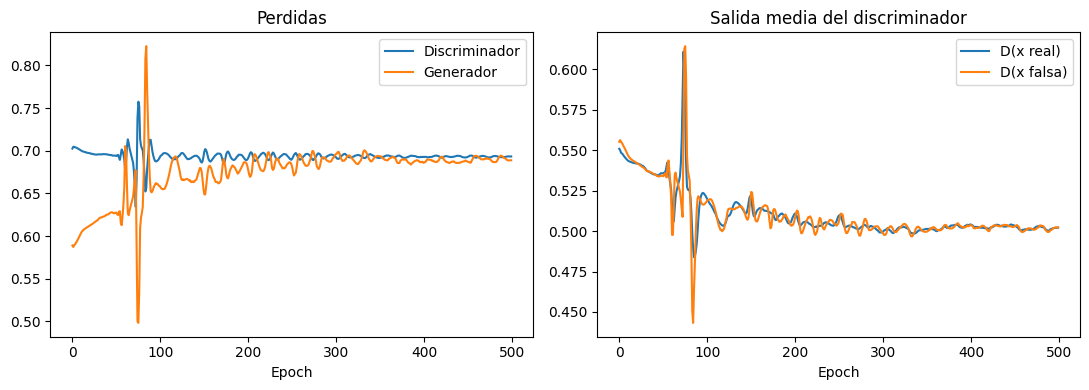

In [8]:
plot_training_history(history_below_tc)


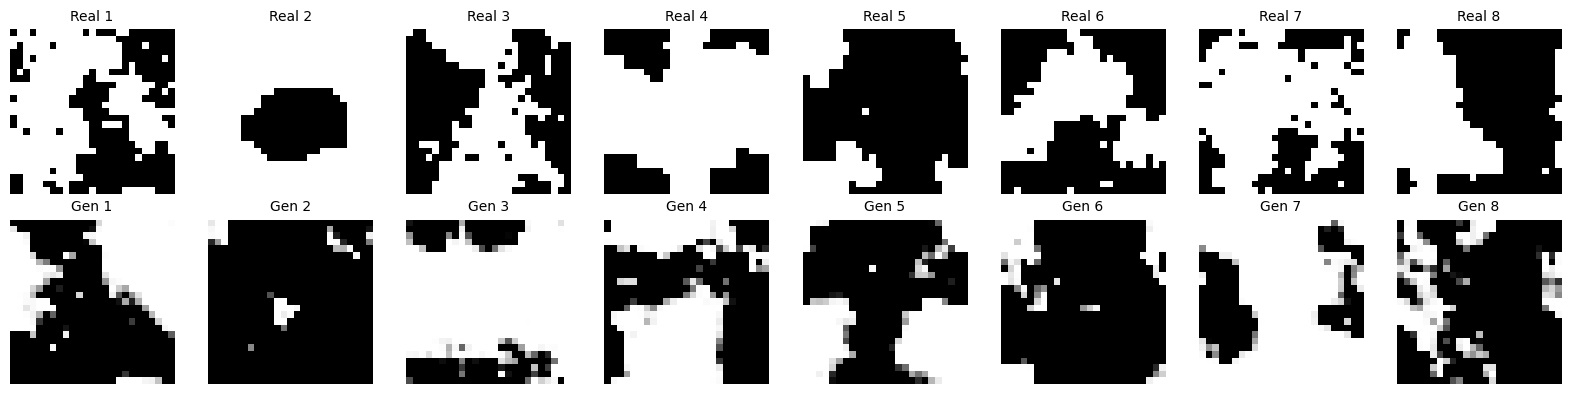

In [31]:
compare_generated_vs_real(generator_below_tc, x_below_tc, n_samples=8)


In [22]:
import torch
from torch import nn
from torch.utils.data import DataLoader

n_samples = 500
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Genera imágenes sintéticas con ambos generadores
z = torch.randn(n_samples, LATENT_DIM, device=device)

# Imágenes generadas por encima de Tc con etiqueta 1
X_above_tc = generator_above_tc(z).detach().cpu()
y_above_tc = torch.ones(X_above_tc.size(0), dtype=torch.long)

# Imágenes generadas por debajo de Tc con etiqueta 0
X_below_tc = generator_below_tc(z).detach().cpu()
y_below_tc = torch.zeros(X_below_tc.size(0), dtype=torch.long)

# Combinamos en un único dataset y hacemos split 80/20
X = torch.cat([X_above_tc, X_below_tc], dim=0)
y = torch.cat([y_above_tc, y_below_tc], dim=0)
dataset = torch.utils.data.TensorDataset(X, y)

n_total = len(dataset)
n_train = int(0.8 * n_total)
n_test = n_total - n_train
torch.manual_seed(42)
train_ds, test_ds = torch.utils.data.random_split(dataset, [n_train, n_test])


In [23]:
# Clasificador CNN binario para distinguir T > Tc de T < Tc
class CNN(nn.Module):
    def __init__(self, input_channels=1, hidden_channels=16, num_classes=1, dropout_p=0.25):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(input_channels, hidden_channels, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 25x25 -> 12x12
            nn.Dropout2d(dropout_p),
            nn.Conv2d(hidden_channels, hidden_channels * 2, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 12x12 -> 6x6
            nn.Dropout2d(dropout_p),
            nn.Flatten(),
            nn.Linear((hidden_channels * 2) * 6 * 6, num_classes),
        )

    def forward(self, x):
        return self.net(x)


In [24]:
def train(model, dataloader, X_test, y_test, criterion, optimizer, num_epochs=50, is_cnn=False):
    train_losses = []
    test_losses = []
    best_test_loss = float("inf")
    best_state_dict = None

    for epoch in range(num_epochs):
        model.train()
        epoch_train_loss = 0.0

        for X_batch, y_batch in dataloader:
            if is_cnn:
                X_batch = X_batch.view(-1, 1, 25, 25)

            y_batch = y_batch.view(-1).float()

            optimizer.zero_grad()
            logits = model(X_batch).view(-1)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()

            epoch_train_loss += loss.item()

        train_loss = epoch_train_loss / len(dataloader)
        train_losses.append(train_loss)

        # Evaluación en el conjunto de prueba sin calcular gradientes
        model.eval()
        with torch.no_grad():
            X_test_eval = X_test.view(-1, 1, 25, 25) if is_cnn else X_test
            y_test_idx = y_test.view(-1).float()
            test_logits = model(X_test_eval).view(-1)
            test_loss = criterion(test_logits, y_test_idx)
            current_test_loss = test_loss.item()
            test_losses.append(current_test_loss)

            # Guardamos el mejor modelo según la pérdida en test
            if current_test_loss < best_test_loss:
                best_test_loss = current_test_loss
                best_state_dict = {k: v.detach().clone() for k, v in model.state_dict().items()}

        if (epoch + 1) % 10 == 0:
            print(
                f"Epoch [{epoch+1}/{num_epochs}], "
                f"Train Loss: {train_loss:.4f}, Test Loss: {current_test_loss:.4f}"
            )

    # Restauramos los pesos del mejor modelo antes de devolver
    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    return train_losses, test_losses


In [25]:
# Pérdida para clasificación binaria (sin activación softmax en la salida)
criterion = nn.BCEWithLogitsLoss()

dataloader_cnn = DataLoader(train_ds, batch_size=16, shuffle=True)

# Tensores de test y train listos para la CNN
X_test_cnn = test_ds.dataset.tensors[0][test_ds.indices].view(-1, 1, 25, 25).float()
y_test_cnn = test_ds.dataset.tensors[1][test_ds.indices]

X_train_cnn = train_ds.dataset.tensors[0][train_ds.indices].view(-1, 1, 25, 25).float()
y_train = train_ds.dataset.tensors[1][train_ds.indices].view(-1)


In [26]:
CNN_model = CNN(input_channels=1, hidden_channels=16, num_classes=1, dropout_p=0.25)
optimizer_cnn = torch.optim.Adam(CNN_model.parameters(), lr=0.001, weight_decay=1e-5)

# Contamos los parámetros entrenables del clasificador
cnn_params = sum(p.numel() for p in CNN_model.parameters() if p.requires_grad)
print(f"CNN parámetros entrenables (exactos): {cnn_params:,}")

CNN_train_losses, CNN_test_losses = train(
    CNN_model,
    dataloader_cnn,
    X_test_cnn,
    y_test_cnn,
    criterion,
    optimizer_cnn,
    num_epochs=100,
    is_cnn=True,
)


CNN parámetros entrenables (exactos): 5,953
Epoch [10/100], Train Loss: 0.0210, Test Loss: 0.0207
Epoch [20/100], Train Loss: 0.0116, Test Loss: 0.0024
Epoch [30/100], Train Loss: 0.0093, Test Loss: 0.0038
Epoch [40/100], Train Loss: 0.0048, Test Loss: 0.0093
Epoch [50/100], Train Loss: 0.0006, Test Loss: 0.0004
Epoch [60/100], Train Loss: 0.0021, Test Loss: 0.0000
Epoch [70/100], Train Loss: 0.0030, Test Loss: 0.0005
Epoch [80/100], Train Loss: 0.0002, Test Loss: 0.0002
Epoch [90/100], Train Loss: 0.0001, Test Loss: 0.0002
Epoch [100/100], Train Loss: 0.0013, Test Loss: 0.0000


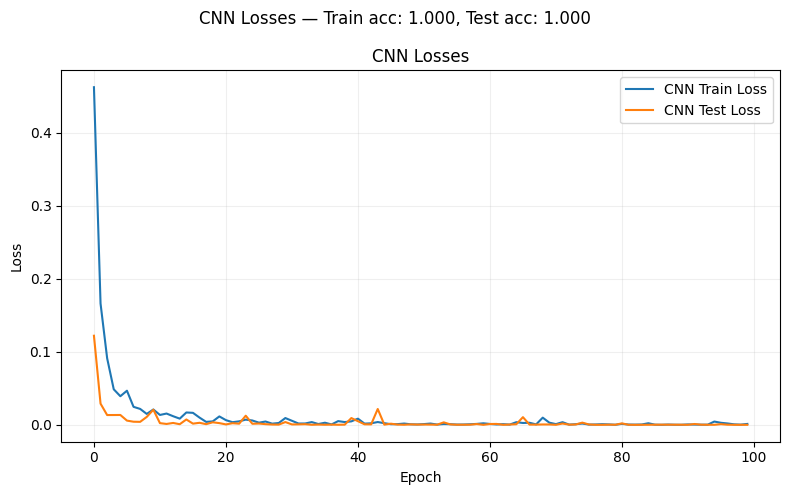

In [27]:
import matplotlib.pyplot as plt

# Graficamos las pérdidas de entrenamiento y prueba del clasificador
plt.figure(figsize=(8, 5))
plt.plot(CNN_train_losses, label="CNN Train Loss")
plt.plot(CNN_test_losses, label="CNN Test Loss")
plt.title("CNN Losses")
plt.xlabel("Epoch")
plt.ylabel("Loss")


# Calcula el accuracy final usando umbral 0.5 sobre la salida sigmoide
def _calc_acc(model, X, y, is_cnn=True):
    model.eval()
    with torch.no_grad():
        X_eval = X.view(-1, 1, 25, 25) if is_cnn else X
        logits = model(X_eval).view(-1)
        predicted = (torch.sigmoid(logits) >= 0.5).long()
        correct = (predicted == y.view(-1).long()).sum().item()
        total = y.size(0)
    return correct / total if total > 0 else 0.0


cnn_train_acc = _calc_acc(CNN_model, X_train_cnn, y_train, is_cnn=True)
cnn_test_acc = _calc_acc(CNN_model, X_test_cnn, y_test_cnn, is_cnn=True)

plt.legend()
plt.grid(alpha=0.2)
plt.suptitle(f"CNN Losses — Train acc: {cnn_train_acc:.3f}, Test acc: {cnn_test_acc:.3f}")
plt.tight_layout()
plt.show()


Nuestro clasificador binario del ejercicio 2 no tiene problemas para separar las imagenes generadas por debajo y por encima de la Tc. Aprende rápido y obtiene una accuracy de 1.0 tanto en el entrenamiento como en el test. Esto puede deberse a que las imágenes son generadas con una red CNN, misma arquitectura que el clasificador, y por lo tanto es capaz de capturar todas las diferencias entre ambos sets. Además, es probable que las redes no aprendan a generar imágenes cerca de la Tc (al menos eso parece en los ejemplos), y por ello podría ser más fácil diferenciarlas.